In [1]:
import os
import pickle
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd


In [2]:
metrics_dir=os.path.join(os.getcwd(),"metrics")
# --- LOAD THE .pkl FILE GENERATED PREVIOUSLY ---
adapt=[0,120,20,2]
test_ds_b4=False


combined_results=[]
for a in adapt:
    if test_ds_b4:
        identifier=f"testing_dsb4_adaptable{a}" if a > 0 else "testing_dsb4"
    else:
        identifier=f"30000_1000_100_adaptable{a}" if a > 0 else "30000_1000_100"
        # identifier="1000_200_median"
    filename = f"channel_metrics_by_network_{identifier}.csv"
    path = os.path.join(metrics_dir, filename)

    if os.path.exists(path):
        df = pd.read_csv(path)
        df["Adapt"] = a  # Add a column to identify the condition
        combined_results.append(df)
        print(f"Loaded: {filename}")
    else:
        print(f"Missing: {filename}")


# Combine all into one DataFrame
all_results_df = pd.concat(combined_results, ignore_index=True)

# Example usage:
print(all_results_df.groupby("Adapt")["F1"].mean())

Loaded: channel_metrics_by_network_30000_1000_100.csv
Loaded: channel_metrics_by_network_30000_1000_100_adaptable120.csv
Loaded: channel_metrics_by_network_30000_1000_100_adaptable20.csv
Loaded: channel_metrics_by_network_30000_1000_100_adaptable2.csv
Adapt
0      0.541775
2      0.582758
20     0.580822
120    0.570676
Name: F1, dtype: float64


In [11]:
def plot_f1_boxplot_by_adapt(df):
    # Remove "Overall" if present
    df = df[df["Dataset"] != "Overall"].copy()

    # Average F1 per (Network, Adapt) over the 4 datasets
    mean_f1_per_net = df.groupby(["Network", "Adapt"])["F1"].mean().reset_index()

    # Prepare data for boxplot
    adapt_values = [0,120,20,2]
    data = [mean_f1_per_net[mean_f1_per_net["Adapt"] == a]["F1"].values for a in adapt_values]
    fig, ax = plt.subplots(figsize=(8, 5))

    # Create a pivot table for easier access: rows = Network, columns = Adapt
    pivot = mean_f1_per_net.pivot(index="Network", columns="Adapt", values="F1")

    # Make sure columns are in correct adapt order
    pivot = pivot[adapt_values]

    # Store adapt-wise F1s per network for later use
    adapt_data = pivot.values  # shape: (n_networks, n_adapt_values)
    network_names = pivot.index.tolist()

    # Draw boxplot
    box = ax.boxplot(data, patch_artist=True, widths=0.6,
                     boxprops=dict(facecolor='orange', color='black'),
                     medianprops=dict(color='black'),
                     whiskerprops=dict(color='black'),
                     capprops=dict(color='black'),
                     flierprops=dict(marker='o', color='gray', alpha=0.0))

    # Plot lines between adapt values for each network
    for row in adapt_data:
        jitter= np.random.normal(0, 0.05, size=len(row))  # Add some jitter for visibility
        ax.plot(range(1, len(adapt_values)+1)+jitter, row,marker='o',linestyle='-', alpha=0.5, color='black')

    ax.set_xticks(range(1, len(adapt_values) + 1))
    ax.set_xticklabels(adapt_values, fontsize=11)
    ax.set_xlabel("Adapt", fontsize=12)
    ax.set_ylabel("Mean F1 (across 4 datasets)", fontsize=12)
    ax.set_title("F1 Score Adaptive Threshold", fontsize=14)
    # ax.set_ylim(0, 1)
    ax.grid(axis='y', linestyle='--', alpha=0.4)

    plt.tight_layout()
    plt.show()
    return fig, ax

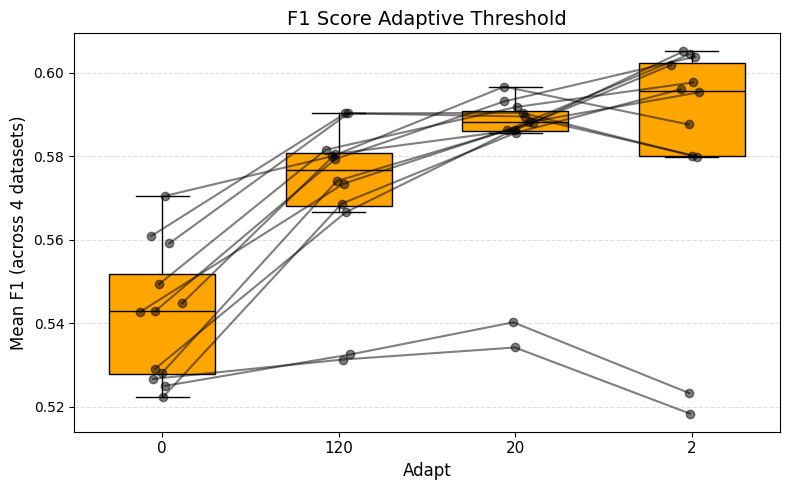

(<Figure size 800x500 with 1 Axes>,
 <Axes: title={'center': 'F1 Score Adaptive Threshold'}, xlabel='Adapt', ylabel='Mean F1 (across 4 datasets)'>)

In [12]:
plot_f1_boxplot_by_adapt(all_results_df)

In [ ]:
def plot_f1_boxplot_by_adapt(df):
    # Remove "Overall" if present
    df = df[df["Dataset"] != "Overall"].copy()

    # Average F1 per (Network, Adapt) over the 4 datasets
    mean_f1_per_net = df.groupby(["Network", "Adapt"])["F1"].mean().reset_index()

    # Prepare data for boxplot
    adapt_values = [0,120,20,2]
    data = [mean_f1_per_net[mean_f1_per_net["Adapt"] == a]["F1"].values for a in adapt_values]
    fig, ax = plt.subplots(figsize=(8, 5))

    # Create a pivot table for easier access: rows = Network, columns = Adapt
    pivot = mean_f1_per_net.pivot(index="Network", columns="Adapt", values="F1")

    # Make sure columns are in correct adapt order
    pivot = pivot[adapt_values]

    # Store adapt-wise F1s per network for later use
    adapt_data = pivot.values  # shape: (n_networks, n_adapt_values)
    network_names = pivot.index.tolist()

    # Draw boxplot
    box = ax.boxplot(data, patch_artist=True, widths=0.6,
                     boxprops=dict(facecolor='orange', color='black'),
                     medianprops=dict(color='black'),
                     whiskerprops=dict(color='black'),
                     capprops=dict(color='black'),
                     flierprops=dict(marker='o', color='gray', alpha=0.0))

    # Plot lines between adapt values for each network
    for row in adapt_data:
        jitter= np.random.normal(0, 0.05, size=len(row))  # Add some jitter for visibility
        ax.plot(range(1, len(adapt_values)+1)+jitter, row,marker='o',linestyle='-', alpha=0.5, color='black')

    ax.set_xticks(range(1, len(adapt_values) + 1))
    ax.set_xticklabels(adapt_values, fontsize=11)
    ax.set_xlabel("Adapt", fontsize=12)
    ax.set_ylabel("Mean F1 (across 4 datasets)", fontsize=12)
    ax.set_title("F1 Score Adaptive Threshold", fontsize=14)
    # ax.set_ylim(0, 1)
    ax.grid(axis='y', linestyle='--', alpha=0.4)

    plt.tight_layout()
    plt.show()
    return fig, ax

In [5]:
from scipy.stats import ttest_ind
from itertools import combinations
import statsmodels.stats.multitest as smm

def test_adapt_groups(df, alpha=0.05):
    """
    Perform pairwise Welch's t-tests on F1 scores across adapt levels,
    with Bonferroni correction for multiple comparisons.

    Parameters:
        df: DataFrame with at least ['Adapt', 'F1'] columns.
        alpha: Significance level for corrected p-values.
    """
    adapt_levels = sorted(df['Adapt'].unique())
    groups = {a: df[df['Adapt'] == a]['F1'].dropna() for a in adapt_levels}
    results = []

    # All pairwise combinations
    for a1, a2 in combinations(adapt_levels, 2):
        g1, g2 = groups[a1], groups[a2]
        stat, p = ttest_ind(g1, g2, equal_var=False)
        results.append((a1, a2, p))

    # Multiple testing correction
    p_raw = [r[2] for r in results]
    reject, p_corrected, _, _ = smm.multipletests(p_raw, alpha=alpha, method='bonferroni')

    # Output results
    print("Pairwise Adapt Comparisons (F1 scores):")
    for i, (a1, a2, raw_p) in enumerate(results):
        sig = "✅" if reject[i] else "❌"
        print(f"{sig} Adapt {a1} vs {a2}: raw p = {raw_p:.4g}, corrected p = {p_corrected[i]:.4g}")


In [6]:
test_adapt_groups(df=all_results_df, alpha=0.05)


Pairwise Adapt Comparisons (F1 scores):
✅ Adapt 0 vs 2: raw p = 3.506e-05, corrected p = 0.0002103
✅ Adapt 0 vs 20: raw p = 3.341e-05, corrected p = 0.0002004
✅ Adapt 0 vs 120: raw p = 0.001488, corrected p = 0.008927
❌ Adapt 2 vs 20: raw p = 0.8475, corrected p = 1
❌ Adapt 2 vs 120: raw p = 0.2178, corrected p = 1
❌ Adapt 20 vs 120: raw p = 0.2758, corrected p = 1


In [41]:
def plot_f1_boxplot_by_dataset_and_adapt(df):
    df = df.copy()
    adapt_values = [0, 120, 20, 2]
    datasets = sorted(df["Dataset"].unique())

    fig, ax = plt.subplots(figsize=(12, 7))

    width = 0.5 # box width per group
    n_adapt = len(adapt_values)
    n_datasets = len(datasets) + 1  # includes "Overall"
    colors = plt.cm.viridis_r(np.linspace(0.2, 0.8, n_adapt))

    # Positions for boxplots
    positions = []
    data = []

    # --- Per-dataset plotting ---
    for i, dataset in enumerate(datasets):
        subset = df[df["Dataset"] == dataset]
        mean_f1_per_net = subset.groupby(["Network", "Adapt"])["F1"].mean().reset_index()
        pivot = mean_f1_per_net.pivot(index="Network", columns="Adapt", values="F1").reindex(columns=adapt_values)

        for j, adapt in enumerate(adapt_values):
            vals = pivot[adapt].dropna().values
            pos = i * (n_adapt + 1) + j
            data.append(vals)
            positions.append(pos)

    # --- "Overall" using mean F1 per Network across datasets ---
    overall_means = df.groupby(["Network", "Adapt"])["F1"].mean().reset_index()
    overall_pivot = overall_means.pivot(index="Network", columns="Adapt", values="F1").reindex(columns=adapt_values)

    overall_pos_start = len(datasets) * (n_adapt + 1)
    for j, adapt in enumerate(adapt_values):
        vals = overall_pivot[adapt].dropna().values
        pos = overall_pos_start + j
        data.append(vals)
        positions.append(pos)

    # --- Boxplots ---
    for idx, (vals, pos) in enumerate(zip(data, positions)):
        color = colors[idx % n_adapt]
        bplot = ax.boxplot(vals, positions=[pos], widths=width, patch_artist=True,
                           showfliers=False, medianprops=dict(color='black'))
        for patch in bplot['boxes']:
            patch.set_facecolor(color)

    # --- X-axis labels ---
    xticks = []
    labels = ["Amigo","Dlx","Som","Thy"]+ ["Overall"]
    for i in range(n_datasets):
        center = i * (n_adapt + 1) + (n_adapt - 1) / 2
        xticks.append(center)
    ax.set_xticks(xticks)
    ax.set_xticklabels(labels, fontsize=12)

    # --- Labels and formatting ---
    ax.set_xlabel("Dataset", fontsize=13)
    ax.set_ylabel("Mean F1 (across Networks)", fontsize=13)
    ax.set_title("F1 Score per Dataset and Adapt Condition", fontsize=16)
    ax.grid(axis='y', linestyle='--', alpha=0.5)

    # --- Legend ---
    adapt_labels = [f"Adapt {a}" for a in adapt_values]
    legend_patches = [plt.Line2D([0], [0], color=colors[i], marker='s', markersize=10,
                                 label=adapt_labels[i]) for i in range(n_adapt)]
    ax.legend(handles=legend_patches, fontsize=12, loc='upper left')

    plt.tight_layout()
    plt.show()
    return fig, ax

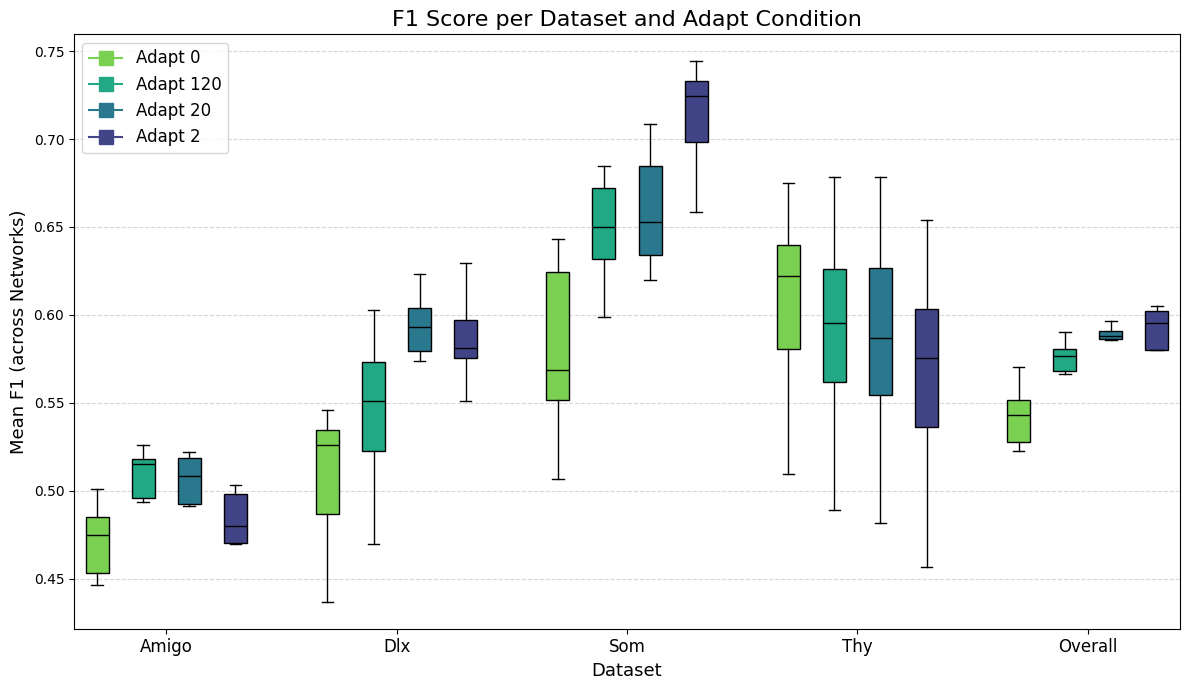

(<Figure size 1200x700 with 1 Axes>,
 <Axes: title={'center': 'F1 Score per Dataset and Adapt Condition'}, xlabel='Dataset', ylabel='Mean F1 (across Networks)'>)

In [42]:
plot_f1_boxplot_by_dataset_and_adapt(all_results_df)

In [35]:
def plot_prf1_boxplot_by_adapt(df):
    df = df[df["Dataset"] != "Overall"].copy()
    metrics = ["Precision", "Recall", "F1"]
    adapt_values = [0, 120, 20, 2]
    colors = {
        "Precision": "royalblue",
        "Recall": "seagreen",
        "F1": "darkorange"
    }

    # Average metric values per (Network, Adapt) across datasets
    mean_metrics_per_net = df.groupby(["Network", "Adapt"])[metrics].mean().reset_index()

    fig, ax = plt.subplots(figsize=(10, 6))
    width = 0.25
    spacing = 0.2

    positions = []
    data = []
    plot_colors = []

    # Track x positions for each adapt-metric combination
    x_base = np.arange(len(adapt_values)) * (len(metrics) * width + spacing)
    xticks = []
    xtick_labels = []

    for i, metric in enumerate(metrics):
        metric_data = []
        for j, adapt in enumerate(adapt_values):
            values = mean_metrics_per_net[mean_metrics_per_net["Adapt"] == adapt][metric].dropna().values
            pos = x_base[j] + i * width
            data.append(values)
            positions.append(pos)
            plot_colors.append(colors[metric])

        # For x-tick labels
        xticks.extend([x_base[j] + width for j in range(len(adapt_values))])
        xtick_labels.extend([str(a) for a in adapt_values])

    # Draw boxplots
    for vals, pos, color in zip(data, positions, plot_colors):
        bplot = ax.boxplot(vals, positions=[pos], widths=width, patch_artist=True,
                           showfliers=False, medianprops=dict(color='black'))
        for patch in bplot['boxes']:
            patch.set_facecolor(color)

    # # Draw per-network connecting lines (for each metric)
    # for metric, color in colors.items():
    #     pivot = mean_metrics_per_net.pivot(index="Network", columns="Adapt", values=metric).reindex(columns=adapt_values)
    #     for row in pivot.values:
    #         if np.isnan(row).any():
    #             continue
    #         jitter = np.random.normal(0, 0.02, size=len(row))  # slight x jitter
    #         x_vals = x_base + metrics.index(metric) * width + jitter
    #         ax.plot(x_vals, row, marker='o', linestyle='-', color=color, alpha=0.4)

    # X-axis settings
    ax.set_xticks(x_base + width)  # center tick on metric group
    ax.set_xticklabels(adapt_values, fontsize=11)
    ax.set_xlabel("Adapt", fontsize=12)

    # Y-axis
    ax.set_ylabel("Score (averaged over datasets)", fontsize=12)
    ax.set_title("Precision, Recall, and F1 vs Adapt", fontsize=14)
    ax.grid(axis='y', linestyle='--', alpha=0.4)
    ax.set_ylim(0, 1.05)

    # Legend
    legend_handles = [plt.Line2D([0], [0], color=colors[m], lw=4, label=m) for m in metrics]
    ax.legend(handles=legend_handles, loc='upper left', fontsize=11)

    plt.tight_layout()
    plt.show()
    return fig, ax

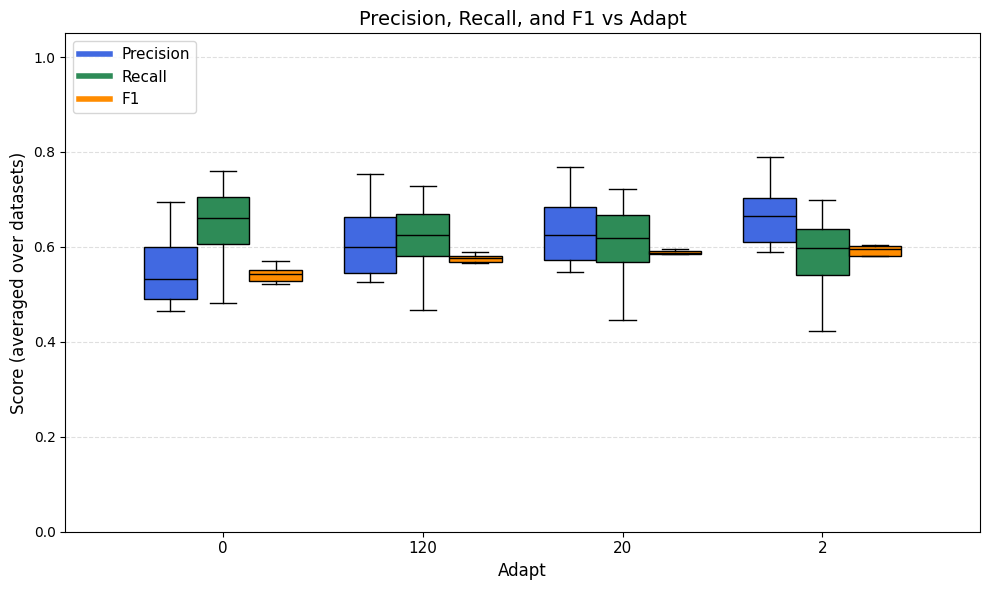

(<Figure size 1000x600 with 1 Axes>,
 <Axes: title={'center': 'Precision, Recall, and F1 vs Adapt'}, xlabel='Adapt', ylabel='Score (averaged over datasets)'>)

In [36]:
plot_prf1_boxplot_by_adapt(all_results_df)

In [37]:
import matplotlib.pyplot as plt
import numpy as np

def plot_precision_recall_by_adapt(df):
    adapt_values = [0, 120, 20, 2]
    adapt_labels = [f"Adapt {a}" for a in adapt_values]
    colors = {
        0: "#E69F00",    # orange
        2: "#009E73",    # green
        20: "#56B4E9",   # sky blue
        120: "#D55E00",  # reddish
    }

    # Average Precision and Recall over datasets per (Network, Adapt)
    grouped = df.groupby(["Network", "Adapt"])[["Precision", "Recall"]].mean().reset_index()

    plt.figure(figsize=(8, 6))

    for adapt in adapt_values:
        subset = grouped[grouped["Adapt"] == adapt]
        plt.scatter(
            subset["Recall"], subset["Precision"],
            label=f"Adapt {adapt}",
            color=colors.get(adapt, "gray"),
            alpha=0.8,
            s=60,
            edgecolors='black'
        )

    plt.xlim(0, 1)
    plt.ylim(0, 1)
    plt.xlabel("Recall", fontsize=12)
    plt.ylabel("Precision", fontsize=12)
    plt.title("Precision vs. Recall by Adapt", fontsize=14)
    plt.legend(title="Adapt", title_fontsize=13, fontsize=12, loc='center left', bbox_to_anchor=(1.01, 0.5))
    plt.grid(True, linestyle='--', alpha=0.6)

    for spine in ['top', 'right']:
        plt.gca().spines[spine].set_visible(False)

    plt.tight_layout()
    plt.show()


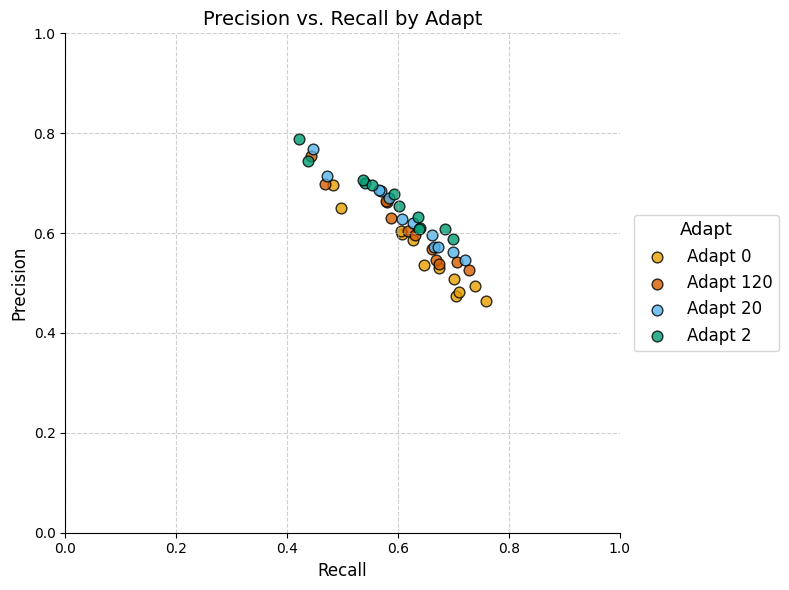

In [38]:
plot_precision_recall_by_adapt(all_results_df)
